In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm 

In [29]:
torch.backends.mps.is_available()

True

In [44]:
device="mps"

In [31]:
#Paths 

train_path = "/Users/Jahnavi/Desktop/Deep Learning/icosimal_img_class_03/data_uniform_224_224_sets/train"
test_path = "/Users/Jahnavi/Desktop/Deep Learning/icosimal_img_class_03/data_uniform_224_224_sets/validate"

In [45]:
#DATA

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.ImageFolder(root=train_path, transform=transform)
test_data = datasets.ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)


print("Classes:", train_data.classes)


Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


In [47]:
#Model

num_classes= len(train_data.classes)

class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7,padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=7,padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.classifier = nn.Sequential( 
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x= self.conv_block1(x)
        x= self.conv_block2(x)
        x=self.classifier(x)
        return x

model = BasicCNN()
model.to(device)
print(model)

BasicCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion.to(device)

CrossEntropyLoss()

In [49]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    
    for images, labels in tqdm(train_loader):
        
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss: .4f}")



100%|█████████████████████████████████████████| 375/375 [01:49<00:00,  3.41it/s]


Epoch 1/5 - Loss:  2.3159


100%|█████████████████████████████████████████| 375/375 [01:40<00:00,  3.75it/s]


Epoch 2/5 - Loss:  2.3028


100%|█████████████████████████████████████████| 375/375 [01:43<00:00,  3.63it/s]


Epoch 3/5 - Loss:  2.3028


100%|█████████████████████████████████████████| 375/375 [01:42<00:00,  3.66it/s]


Epoch 4/5 - Loss:  2.3028


100%|█████████████████████████████████████████| 375/375 [01:51<00:00,  3.37it/s]

Epoch 5/5 - Loss:  2.3028


In [34]:
y_true =[]
y_pred= []

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images= images.to(device)
        labels= labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(f"Test Accuracy: {100 * correct / total:.2f}%")

from sklearn.metrics import confusion_matrix
labelscm= [0,1,2,3,4,5,6,7,8,9]
cm= confusion_matrix(y_true, y_pred, labels=labelscm)
print(cm)


100%|███████████████████████████████████████████| 94/94 [00:12<00:00,  7.70it/s]

Test Accuracy: 41.78%
[[239  36  22  77  17  37  57  26  73  16]
 [ 44 303  22  38  15  29  45  23  67  14]
 [ 37  43 158  45  41 101  20  95  39  21]
 [120  46  28 131  30  66  51  46  75   7]
 [ 32  19  27  32 234  93  29  56  46  32]
 [ 58  31  54  55  51 249  18  33  29  22]
 [ 68  44  25  50  20  24 224  39  95  11]
 [ 33  27  57  43  37  52  32 249  38  32]
 [ 68  71  18  37  21  24  69  26 246  20]
 [  8   8  22   6  18  20  16  13  15 474]]


In [50]:
import numpy as np

y_true = np.array(y_true)
y_true.sum()

np.int64(27000)

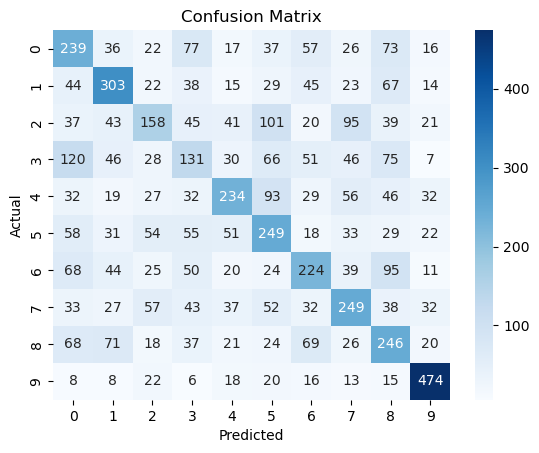

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ["cat","chicken","cow","dog","elephant","horse","rabbit","sheep","squirrel","zebra"]
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [57]:
def train_model(model, train_loader, test_loader, lr, optimizer_name, epochs=5):
    import torch.optim as optim

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()

    for epoch in tqdm (range(epochs)):
        model.train()
        for x,y in train_loader:
            x= x.to(device)
            y= y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

    model.eval()
    correct=0
    total=0

    with torch.no_grad():
        for x,y in test_loader:
            x=x.to(device)
            y=y.to(device)
            outputs = model(x)
            _, predictions = torch.max(outputs, 1)
            correct += (predictions == y).sum().item()
            total += y.size(0)
        
    return correct / total

In [ ]:
learning_rates= [0.1,0.01,0.001]
optimizers = ["SGD", "Adam"]
batch_sizes = [32, 64]

results = []

for lr in learning_rates:
    for opt in optimizers:
        for bs in batch_sizes:
            train_loader= DataLoader(train_data, batch_size=bs, shuffle=True)
            test_loader= DataLoader(test_data, batch_size=bs)

            model= BasicCNN().to(device)

            acc= train_model(model, train_loader, test_loader, lr, opt, epochs=5)

            results.append((lr, opt, bs, acc))
            print(f"LR={lr}, OPT={opt}, BS={bs}, Acc={acc:.4f}")

 60%|███████████████████████████                  | 3/5 [04:32<03:00, 90.42s/it]